# Server pipeline demo

`frames` (mock: data/*.png) → `gate` (is the frame worth a call?) → `perception` (Grok: is the predicate true?).

Needs `XAI_API_KEYS` in `.env`.

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent  # repo root (notebook lives in notebooks/)
sys.path.insert(0, str(ROOT))

from src import config
from src.server.cv.frames import sample_frames
from src.server.cv.gate import THRESHOLD, Gate, board, decode
from src.server.cv.perception import GrokPerception

PREDICATE = "a cat is on the table"
frames = list(sample_frames(ROOT / "data"))
print(f"model={config.XAI_MODEL} keys={len(config.XAI_API_KEYS)} frames={[n for n, _ in frames]}")

model=grok-4.6 keys=1 frames=['1.png', '2.png', '3.png']


In [3]:
# Gate: compare each frame with the anchor. 'first' is always sent; a 'change' must hold PERSIST frames in the same tiles.
gate = Gate()
images = {name: decode(jpeg) for name, jpeg in frames}
gate_log = {name: gate.observe(img) for name, img in images.items()}
for name, r in gate_log.items():
    print(f"{name}: {r.verdict:6s} streak={r.streak} send={r.send}")

print(f"\nloudest tile 1->2: {board(images['1.png'], images['2.png']).max():.1f}"
      f"  2->3: {board(images['2.png'], images['3.png']).max():.1f}  threshold={THRESHOLD}")

1.png: first  streak=0 send=True
2.png: change streak=1 send=False
3.png: change streak=1 send=False

loudest tile 1->2: 17.3  2->3: 19.6  threshold=6.6


1.png -> 2.png: loudest tile 17.3, loud share 0.02 -> change
2.png -> 3.png: loudest tile 19.6, loud share 0.05 -> change


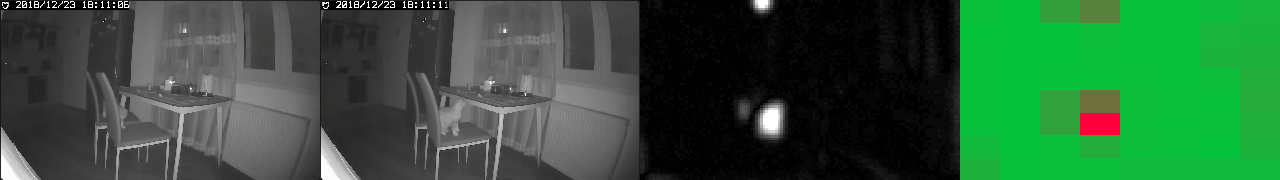

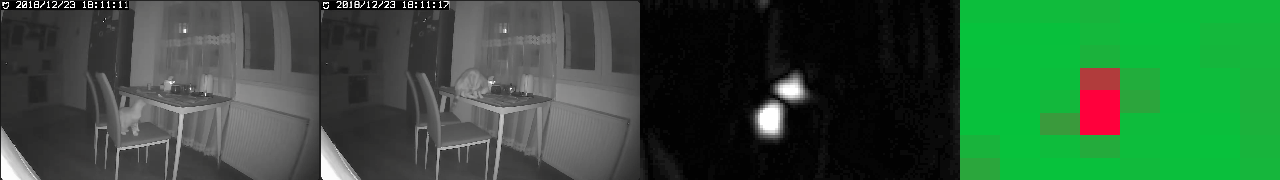

In [7]:
# Picture of each gate decision: anchor · frame · difference x8 · 8x8 tile board (green quiet -> red loud).
import cv2
import numpy as np
from IPython.display import display
from PIL import Image

from src.server.cv.gate import GRID, prep


def heat(b: np.ndarray) -> np.ndarray:
    red = np.clip(b / (2 * THRESHOLD), 0, 1)
    rgb = np.stack([red * 255, (1 - red) * 200, np.full_like(red, 60)], axis=-1).astype(np.uint8)
    return cv2.resize(rgb, (GRID * 24, GRID * 24), interpolation=cv2.INTER_NEAREST)


def compare(a: np.ndarray, b: np.ndarray, size=(320, 180)) -> Image.Image:
    diff = np.abs(prep(a) - prep(b)).max(axis=2)
    loud = cv2.cvtColor(np.clip(diff * 8, 0, 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    panels = [a, b, loud, heat(board(a, b))]
    return Image.fromarray(np.hstack([cv2.resize(p, size, interpolation=cv2.INTER_NEAREST) for p in panels]))


names = list(images)
for prev, cur in zip(names, names[1:]):
    b = board(images[prev], images[cur])
    print(f"{prev} -> {cur}: loudest tile {b.max():.1f}, loud share {(b > THRESHOLD).mean():.2f} -> {gate_log[cur].verdict}")
    display(compare(images[prev], images[cur]))

In [4]:
# Perception: one Grok call per frame (in parallel), same bytes the UI will send.
import asyncio

perception = GrokPerception(config.XAI_API_KEYS, config.XAI_MODEL)
rule = await perception.normalize("the cat jumps onto the table")
observations = dict(zip(
    [n for n, _ in frames],
    await asyncio.gather(*(perception.detect(jpeg, rule.predicate) for _, jpeg in frames)),
))
await perception.aclose()

print(f"rule -> {rule}\n")
for name, obs in observations.items():
    print(f"{name}: state={obs.state!s:5s} {obs.evidence}")

rule -> Rule(predicate='a cat is on the table', direction='rising', is_transition=True)

1.png: state=False table shows objects only, no cat
2.png: state=False cat standing on chair, not table
3.png: state=True  light cat hunched on dining table


predicate: 'a cat is on the table'


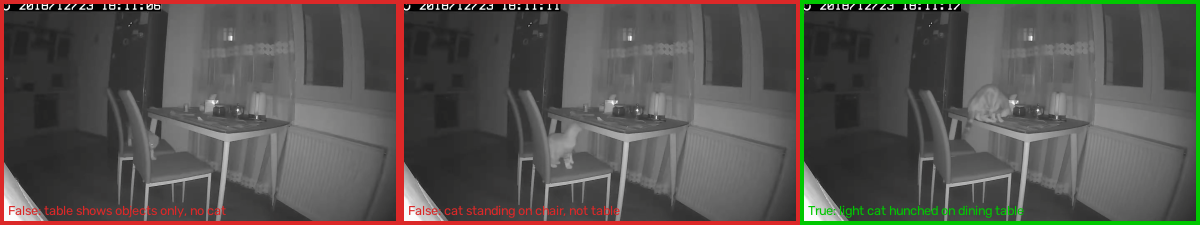

In [8]:
# Each frame with the model's verdict: green = predicate true, red = false.
def labelled(img: np.ndarray, obs, size=(400, 225)) -> np.ndarray:
    out = cv2.resize(img, size, interpolation=cv2.INTER_AREA).copy()
    colour = (0, 200, 0) if obs.state else (220, 40, 40)
    cv2.rectangle(out, (0, 0), (size[0] - 1, size[1] - 1), colour, 6)
    cv2.putText(out, f"{obs.state}: {obs.evidence[:34]}", (8, size[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, colour, 1, cv2.LINE_AA)
    return out


print(f"predicate: {rule.predicate!r}")
display(Image.fromarray(np.hstack([labelled(images[n], observations[n]) for n in images])))

In [5]:
# Checks: expected values for the sample frames.
assert gate_log["1.png"].verdict == "first" and gate_log["1.png"].send
assert board(images["1.png"], images["2.png"]).max() > THRESHOLD  # cat appeared: loud
assert (rule.predicate, rule.direction, rule.is_transition) == ("a cat is on the table", "rising", True)
assert {n: o.state for n, o in observations.items()} == {"1.png": False, "2.png": False, "3.png": True}
print("ok")

ok
